# 🫀 Heart Disease Prediction with Random Forest
### Machine Learning Assignment — Random Forest Classification

---

**Dataset:** UCI Heart Disease Dataset (Cleveland Clinic Foundation)  
**Goal:** Predict whether a patient has heart disease based on clinical features  
**Skills Practiced:** EDA, Data Visualization, Random Forest, Model Evaluation, Feature Importance

---

## 📖 Dataset Description

This dataset contains **303 patient records** with **13 clinical features** collected from the Cleveland Clinic. Your goal is to predict the `target` column:
- `0` → No Heart Disease  
- `1` → Heart Disease Present

### Feature Dictionary

| Feature | Description |
|---|---|
| `age` | Age of the patient (years) |
| `sex` | Sex (1 = male, 0 = female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = True, 0 = False) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = Yes, 0 = No) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of peak exercise ST segment (0–2) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect) |
| `target` | **Diagnosis** (1 = Heart Disease, 0 = No Disease) |

---

> ⚠️ **Instructions:** Complete each task below. Cells marked with `# YOUR CODE HERE` need your implementation.  
> 💡 Hints are provided in comments — read them carefully before writing code!

## 📦 Section 0: Import Libraries

In [1]:
# All required libraries are imported for you.
# Feel free to add more if needed!

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

import warnings
warnings.filterwarnings('ignore')

# Set a consistent style for all plots
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## 📂 Section 1: Load the Dataset

**Task 1.1** — Load the Heart Disease dataset and display the first few rows.

In [9]:
# The dataset is publicly available from UCI ML Repository via this URL.
# We rename the columns manually since the raw file has no header.

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak',
                'slope', 'ca', 'thal', 'target']

# 💡 Hint: Use pd.read_csv() with the url above.
#          Pass na_values='?' to handle missing values encoded as '?'.
#          Pass names=column_names to set column headers.

# YOUR CODE HERE
df = pd.read_csv(url, na_values='?', names=column_names)

# Display the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---

## ✅ Task 1.2 — Convert Target to Binary

The original dataset's `target` column can have values 0, 1, 2, 3, 4. As per the problem description, any value greater than 0 indicates 'Heart Disease Present' (1), while `0` means 'No Heart Disease'.

In [10]:
# =========================
# IMPORT (safe for standalone cell)
# =========================
import pandas as pd

# =========================
# LOAD DATASET (ONLY if df not already loaded)
# =========================
if 'df' not in globals():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

    column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                    'restecg', 'thalach', 'exang', 'oldpeak',
                    'slope', 'ca', 'thal', 'target']

    df = pd.read_csv(url, na_values='?', names=column_names)

    # Handle missing values
    df['ca'] = df['ca'].fillna(df['ca'].median())
    df['thal'] = df['thal'].fillna(df['thal'].median())

# =========================
# CONVERT TARGET TO BINARY
# =========================
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# =========================
# OUTPUT CHECK
# =========================
print("Target value counts after conversion:")
print(df['target'].value_counts())

print("\nFirst 5 rows after target conversion:")
print(df.head())

Target value counts after conversion:
target
0    164
1    139
Name: count, dtype: int64

First 5 rows after target conversion:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [11]:
import pandas as pd

# =========================
# LOAD DATASET (SAFE CHECK)
# =========================
if 'df' not in globals():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

    column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                    'restecg', 'thalach', 'exang', 'oldpeak',
                    'slope', 'ca', 'thal', 'target']

    df = pd.read_csv(url, na_values='?', names=column_names)

    # handle missing values
    df['ca'] = df['ca'].fillna(df['ca'].median())
    df['thal'] = df['thal'].fillna(df['thal'].median())

# =========================
# DISPLAY DATA
# =========================
print("First 5 rows of dataset:")
print(df.head())

# =========================
# BASIC INFO
# =========================
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows of dataset:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  30

---
## 🔍 Section 2: Exploratory Data Analysis (EDA)

Before building any model, always understand your data! Answer the questions below.

In [7]:
# ✅ TASK 2.1 — Get a summary of the dataset.
# Print:
#   (a) Shape of the dataset
#   (b) Data types of each column
#   (c) Number of missing values per column
#   (d) Basic statistics using .describe()

# YOUR CODE HERE
# (a) Shape of the dataset
print("Shape:", df.shape)

# (b) Data types of each column
print("\nData types:")
print(df.dtypes)

# (c) Number of missing values per column
print("\nMissing values:")
print(df.isnull().sum())

# (d) Basic statistics
print("\nDescriptive Statistics:")
print(df.describe())
print("Shape:", ___)
print("\nData types:")
print(___)
print("\nMissing values:")
print(___)
print("\nDescriptive Statistics:")
___

Shape: (303, 14)

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Descriptive Statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000   

''

In [8]:
# Fill missing values in 'ca' and 'thal' with median

df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

# Verify no more missing values
print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


---
## 📊 Section 3: Data Visualization

Create meaningful visualizations to understand the data. Each plot should have proper **titles**, **axis labels**, and **legends** where needed.

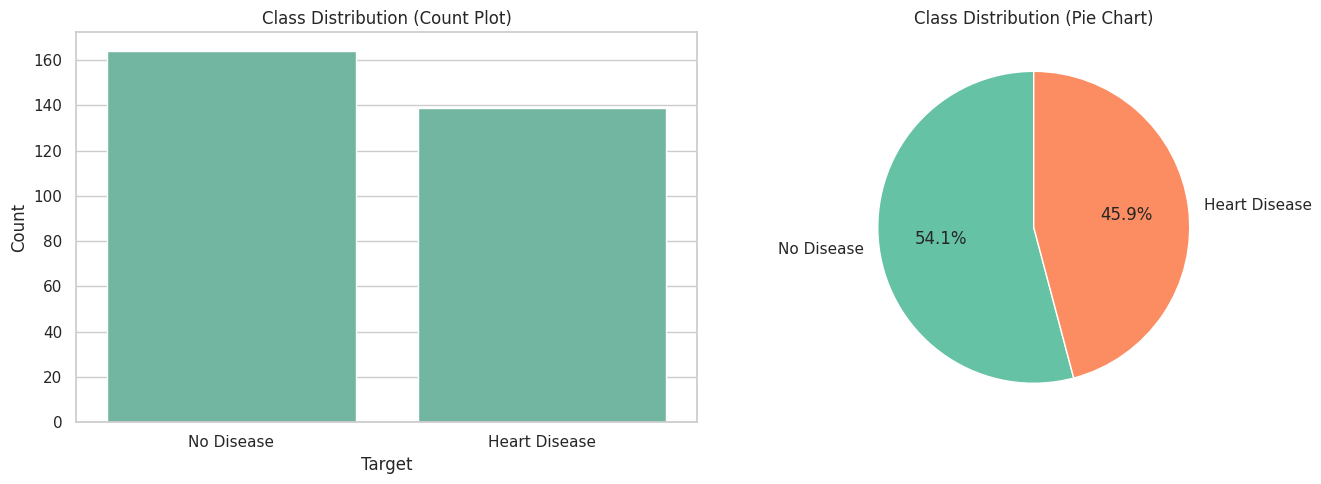

In [12]:
# =========================
# IMPORT LIBRARIES (if not already)
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# Left plot: Count plot
# =========================
sns.countplot(x='target', data=df, ax=axes[0])

axes[0].set_title("Class Distribution (Count Plot)")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Count")

# Replace 0/1 with labels
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease', 'Heart Disease'])


# =========================
# Right plot: Pie chart
# =========================
target_counts = df['target'].value_counts()

axes[1].pie(
    target_counts,
    labels=['No Disease', 'Heart Disease'],
    autopct='%1.1f%%',
    startangle=90
)

axes[1].set_title("Class Distribution (Pie Chart)")


plt.tight_layout()
plt.show()

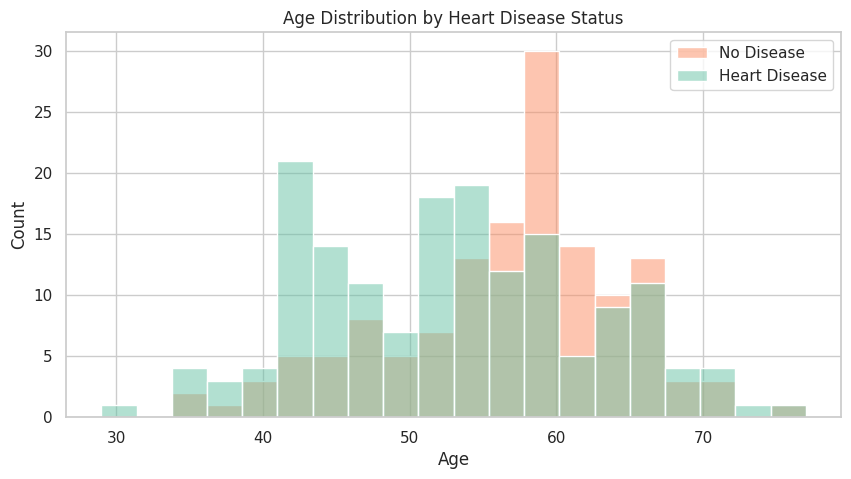

In [13]:
plt.figure(figsize=(10, 5))

# Histogram with overlap
sns.histplot(data=df, x='age', hue='target', bins=20, alpha=0.5)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")

# Legend labels
plt.legend(['No Disease', 'Heart Disease'])

plt.show()

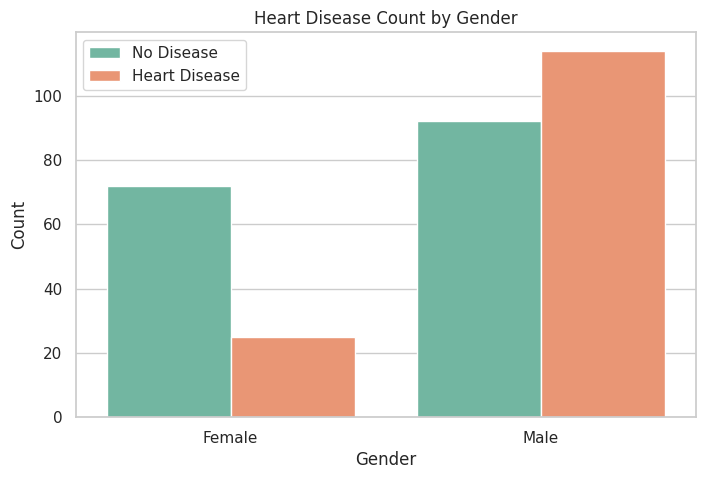

In [15]:

plt.figure(figsize=(8, 5))

# Grouped bar chart
sns.countplot(x='sex', hue='target', data=df)

plt.title("Heart Disease Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

# Replace 0/1 with meaningful labels
plt.xticks([0, 1], ['Female', 'Male'])

# Legend labels (fixing default legend issue)
plt.legend(['No Disease', 'Heart Disease'])

plt.show()

<Figure size 1200x800 with 0 Axes>

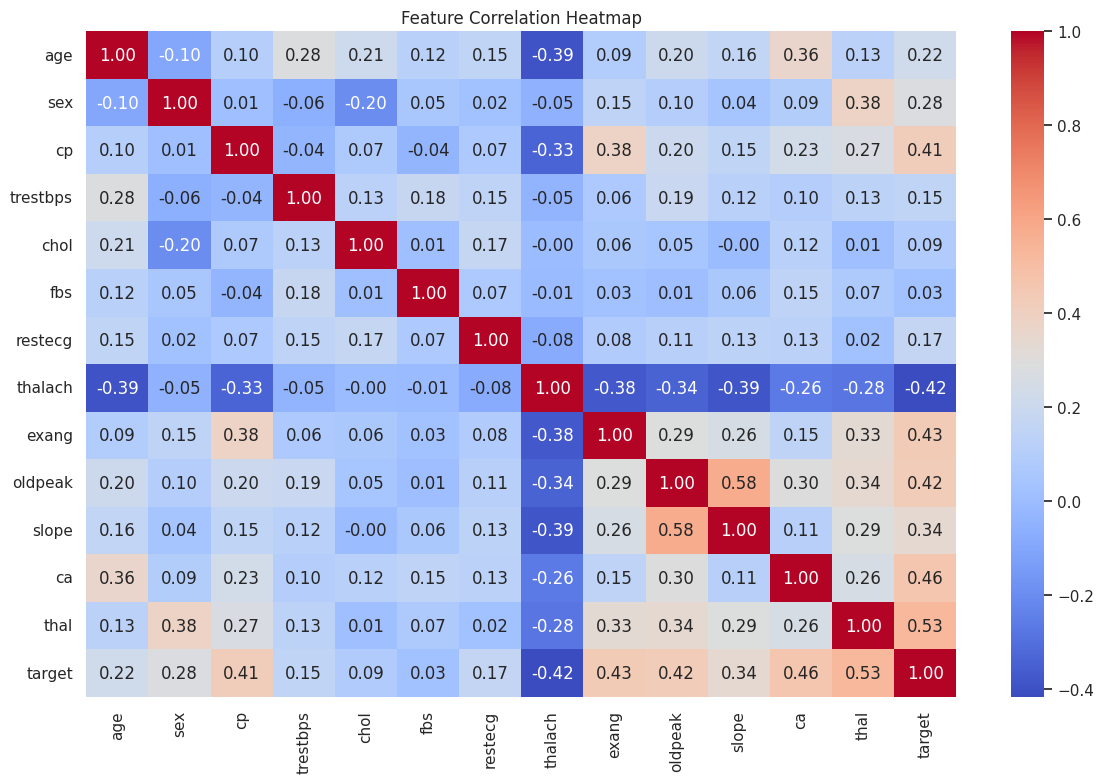

In [17]:
# ✅ TASK 3.4 — Correlation Heatmap
# Plot a heatmap of the correlation matrix for all numeric features.
# This shows which features are linearly related to each other.

# 💡 Hint: Use df.corr() to compute correlations.
#          Use sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
#          Set annot=True to show correlation values inside each cell.

plt.figure(figsize=(12, 8))

# YOUR CODE HERE

plt.figure(figsize=(12, 8))

# Correlation matrix
corr = df.corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 🤔 Question: Which feature has the highest positive correlation with 'target'?
# Write your answer in a comment below:
# Answer:

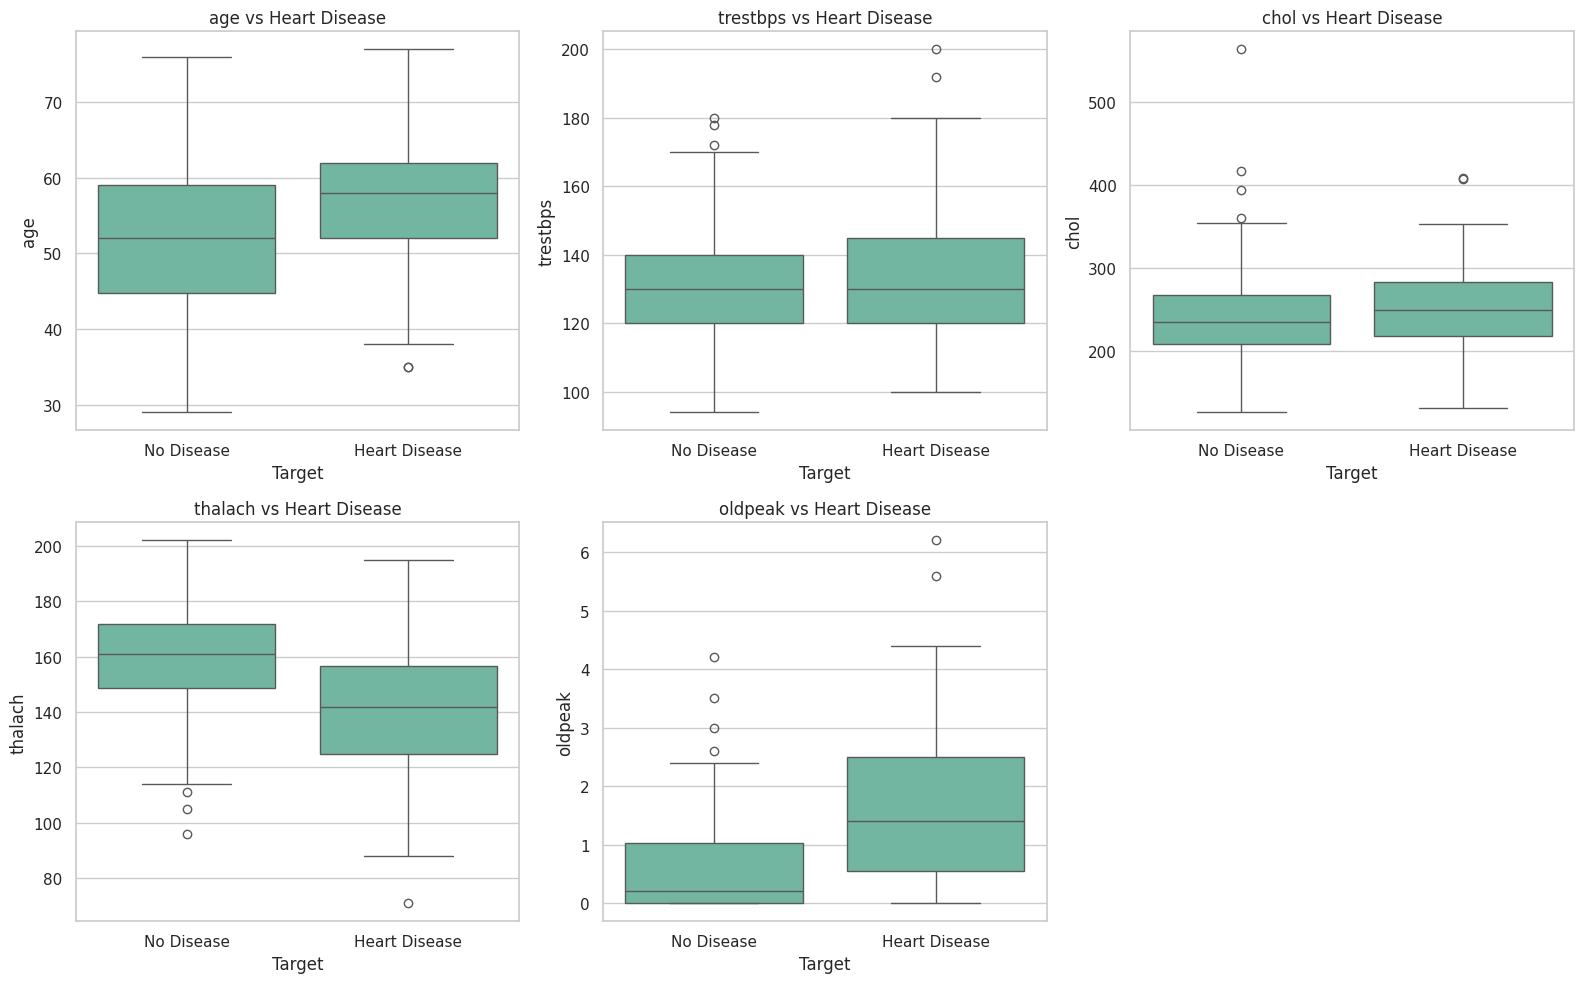

<Figure size 1000x600 with 0 Axes>

In [20]:
# ✅ TASK 3.5 — Boxplots: Numerical Features vs Target
# Create boxplots for the following features split by target:
# 'age', 'trestbps', 'chol', 'thalach', 'oldpeak'

# 💡 Hint: Use plt.subplots() to create a grid of 2x3 subplots (or similar).
#          Use sns.boxplot(x='target', y=feature, data=df, ax=axes[i]) in a loop.

num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# YOUR CODE HERE (loop through num_features and plot each boxplot)
for i, feature in enumerate(num_features):
    sns.boxplot(x='target', y=feature, data=df, ax=axes[i])

    axes[i].set_title(f'{feature} vs Heart Disease')
    axes[i].set_xlabel("Target")
    axes[i].set_xticklabels(['No Disease', 'Heart Disease'])

# Hide empty subplot (6th one)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

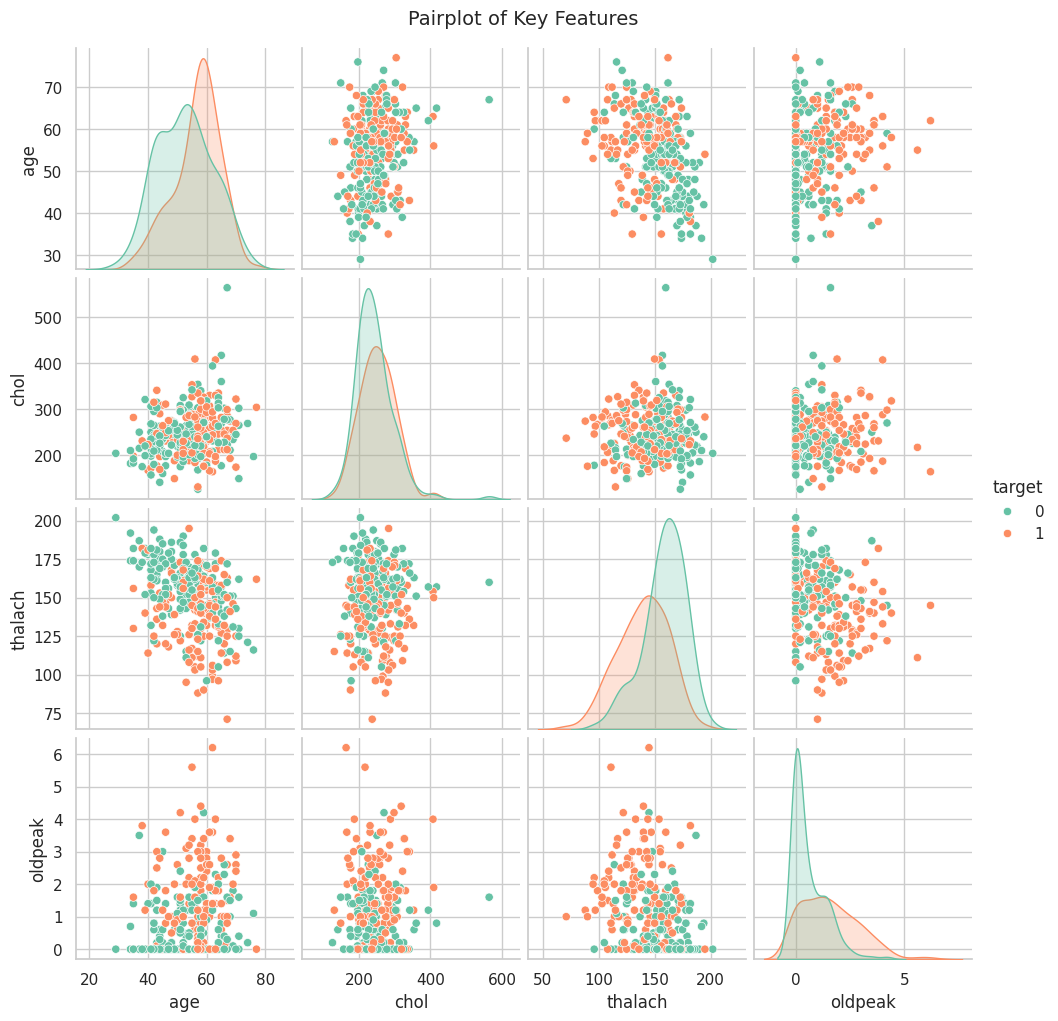

<Figure size 1000x600 with 0 Axes>

In [21]:
# ✅ TASK 3.6 — Pairplot (BONUS)
# Create a pairplot for a subset of features to visualize pairwise relationships.
# Use: ['age', 'chol', 'thalach', 'oldpeak', 'target']

# 💡 Hint: Use sns.pairplot(df[features], hue='target', diag_kind='kde')
#          This might take a few seconds to render!

# YOUR CODE HERE
features = ['age', 'chol', 'thalach', 'oldpeak', 'target']

# Pairplot
sns.pairplot(df[features], hue='target', diag_kind='kde')

plt.suptitle("Pairplot of Key Features", y=1.02, fontsize=14)
plt.show()

plt.suptitle("Pairplot of Key Features", y=1.02, fontsize=14)
plt.show()

---
## 🛠️ Section 4: Feature Preparation & Train-Test Split

In [22]:
# ✅ TASK 4.1 — Separate Features and Target
# X should contain all columns EXCEPT 'target'
# y should contain only the 'target' column

# 💡 Hint: Use df.drop('target', axis=1) for X

# YOUR CODE HERE
X = df.drop('target', axis=1)
y = df['target']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:", list(X.columns))

Feature matrix shape: (303, 13)
Target shape: (303,)

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [23]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Testing set size:   {X_test.shape[0]} samples")

print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())

Training set size:  242 samples
Testing set size:   61 samples

Class distribution in training set:
target
0    131
1    111
Name: count, dtype: int64


---
## 🌲 Section 5: Random Forest — Building the Model

Now for the main event! Build, train, and evaluate a Random Forest classifier.

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained!")
print(f"Number of trees: {rf_model.n_estimators}")

✅ Random Forest model trained!
Number of trees: 100


In [25]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions on test set
y_pred = rf_model.predict(X_test)

# Accuracy on training set
train_acc = accuracy_score(y_train, rf_model.predict(X_train))

# Accuracy on test set
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 1.0000
Test Accuracy:     0.8852

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



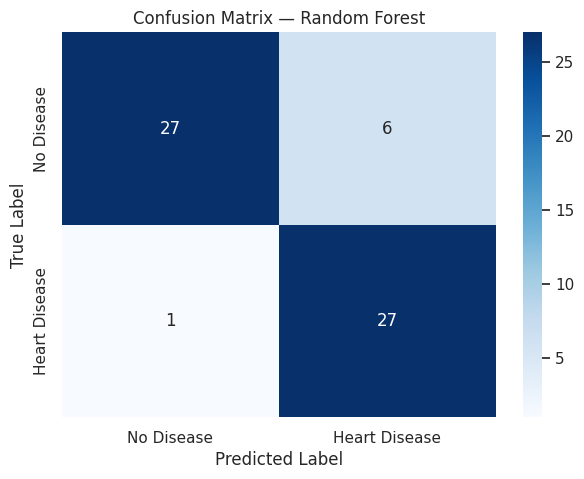

In [26]:
# ✅ TASK 5.3 — Confusion Matrix Visualization
# Plot a confusion matrix heatmap to visualize model predictions.

# 💡 Hint: Use ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
#          OR compute confusion_matrix(y_test, y_pred) then plot with sns.heatmap.
#          Label the axes clearly: 'No Disease' and 'Heart Disease'.

plt.figure(figsize=(7, 5))

# YOUR CODE HERE


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix — Random Forest")
plt.show()

# 🤔 Question: How many False Positives and False Negatives does your model produce?
# Why does a False Negative matter more in a medical context?
# Answer:

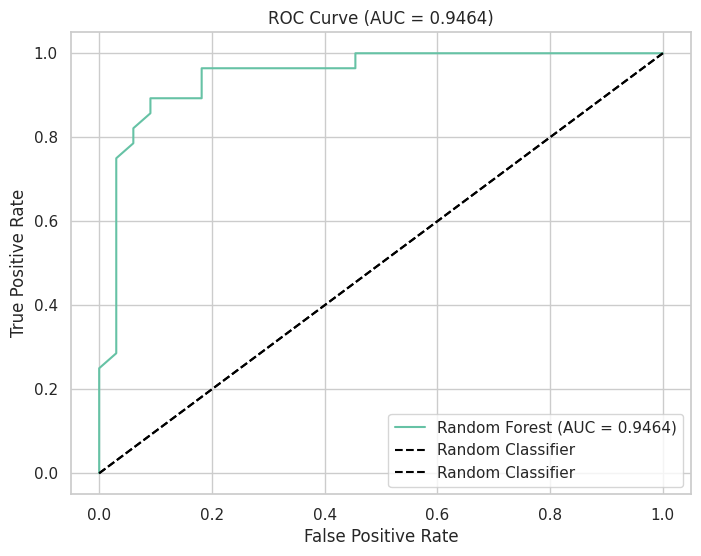

In [30]:
# ✅ TASK 5.4 — ROC Curve & AUC Score
# Plot the ROC (Receiver Operating Characteristic) curve and compute the AUC score.

# 💡 Hint: Use rf_model.predict_proba(X_test)[:, 1] to get probability scores.
#          Then roc_curve(y_test, y_scores) returns fpr, tpr, thresholds.
#          Plot fpr on x-axis and tpr on y-axis.
#          Add a diagonal dashed line for the 'random classifier' baseline.

y_scores = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

auc_score = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# YOUR CODE HERE (plot the ROC curve)

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.4f})")

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')



plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.4f})")
plt.legend()
plt.show()

---
## 🔬 Section 6: Understanding the Forest — Feature Importance

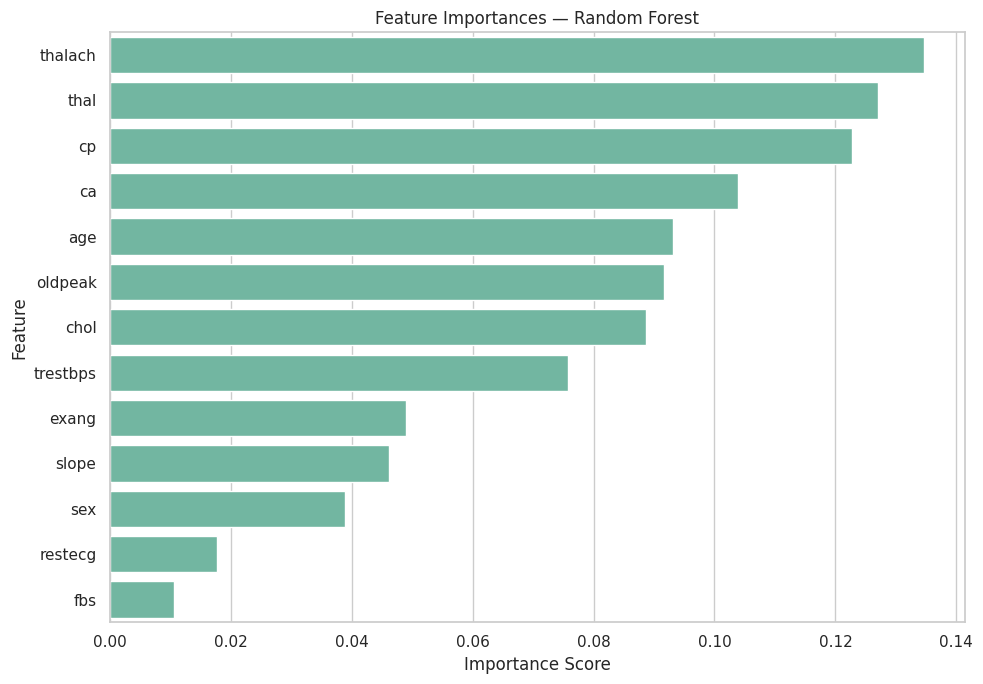

In [31]:
# ✅ TASK 6.1 — Plot Feature Importances
# Random Forests can tell you which features were most useful for prediction.
# Extract and plot feature importances as a horizontal bar chart.

# 💡 Hint: rf_model.feature_importances_ gives a numpy array of importances.
#          Create a DataFrame with columns ['Feature', 'Importance'].
#          Sort by Importance (descending) and plot with sns.barplot().

importances = rf_model.feature_importances_
feature_names = X.columns

# YOUR CODE HERE — create a sorted DataFrame


# YOUR CODE HERE — plot horizontal bar chart

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))

# Horizontal bar plot
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 🤔 Question: What are the top 3 most important features?
# Do they align with medical knowledge about heart disease risk factors?
# Answer:

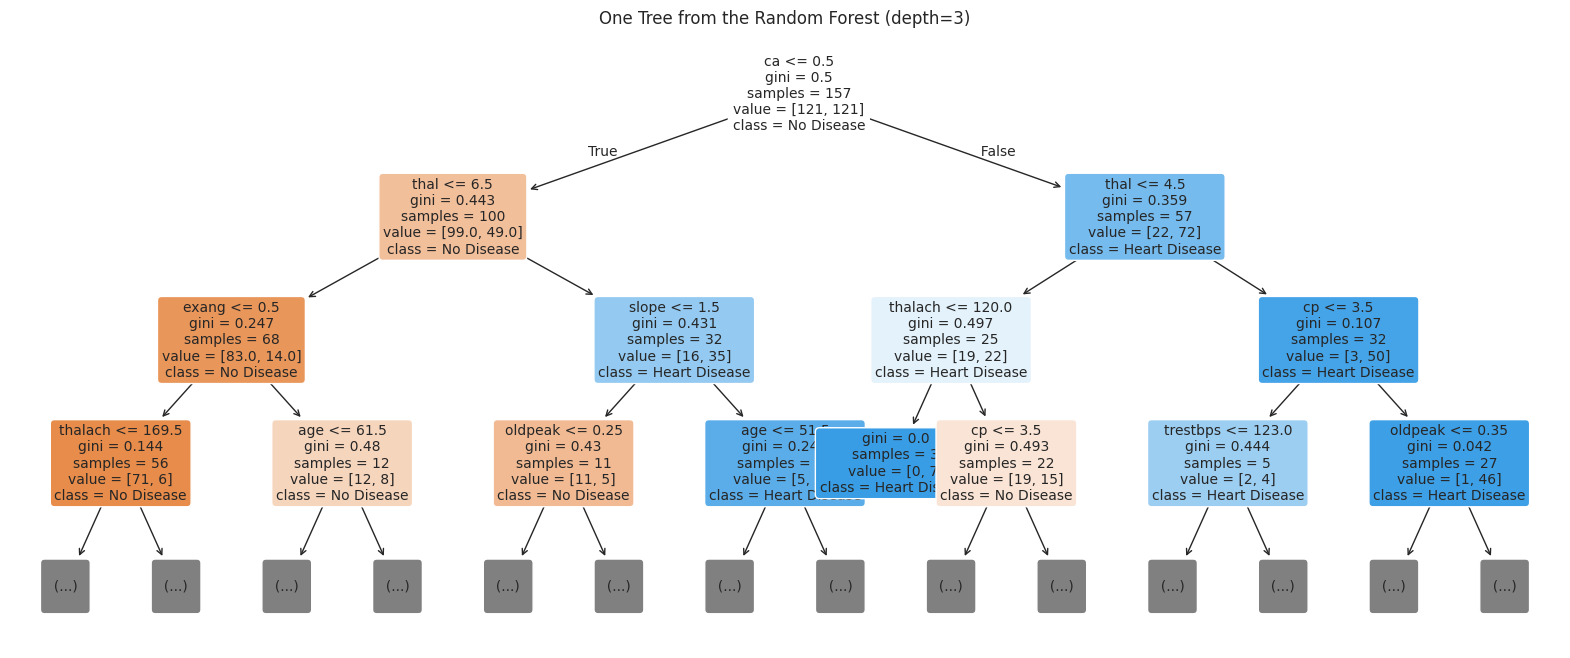

In [32]:
# ✅ TASK 6.2 — Visualize One Tree from the Forest (BONUS)
# Visualize the first decision tree inside your random forest.
# Limit depth to 3 for readability.

# 💡 Hint: rf_model.estimators_[0] gives the first tree.
#          Use plot_tree(tree, max_depth=3, feature_names=..., class_names=..., filled=True)

plt.figure(figsize=(20, 8))

# YOUR CODE HERE
single_tree = rf_model.estimators_[0]

# Plot tree
plot_tree(
    single_tree,
    max_depth=3,
    feature_names=list(X.columns),
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=10
)


plt.title("One Tree from the Random Forest (depth=3)")
plt.show()

---
## ⚙️ Section 7: Hyperparameter Tuning

A Random Forest has many knobs to tune. Let's find the best combination!

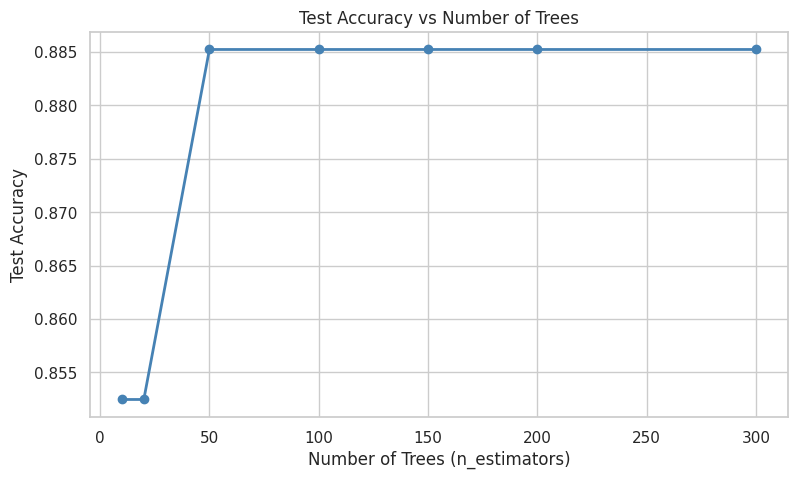

In [35]:
# ✅ TASK 7.1 — Effect of n_estimators on Accuracy
# Train Random Forests with different numbers of trees and plot how
# test accuracy changes as n_estimators increases.

# 💡 Hint: Loop over n_values = [10, 20, 50, 100, 150, 200, 300]
#          For each value, train a new RF and record the test accuracy.
#          Then plot n_values (x-axis) vs accuracies (y-axis).

n_values = [10, 20, 50, 100, 150, 200, 300]
test_accuracies = []

# YOUR CODE HERE
for n in n_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    test_accuracies.append(acc)

# Plot results
plt.figure(figsize=(9, 5))
plt.plot(n_values, test_accuracies, marker='o', linewidth=2, color='steelblue')

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Number of Trees")
plt.grid(True)

plt.show()




# 🤔 At what point does adding more trees stop improving accuracy significantly?
# Answer:

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# =========================
# SAFETY CHECK (recreate data if missing)
# =========================
if 'df' not in globals():
    import pandas as pd

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

    column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                    'restecg', 'thalach', 'exang', 'oldpeak',
                    'slope', 'ca', 'thal', 'target']

    df = pd.read_csv(url, na_values='?', names=column_names)

    df['ca'] = df['ca'].fillna(df['ca'].median())
    df['thal'] = df['thal'].fillna(df['thal'].median())

    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# =========================
# CREATE X AND Y (SAFE)
# =========================
X = df.drop('target', axis=1)
y = df['target']

# =========================
# TRAIN-TEST SPLIT (FIX)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# GRID SEARCH
# =========================
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 0.8303571428571429


In [17]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Best model from GridSearchCV
best_model = grid_search.best_estimator_

# Predictions (tuned model)
y_pred_tuned = best_model.predict(X_test)

# Accuracy of tuned model
tuned_acc = accuracy_score(y_test, y_pred_tuned)

# Baseline model accuracy (SAFE CHECK)
# If test_acc is not defined, or rf_model is not defined, re-train a baseline model.
if 'test_acc' not in globals() or 'rf_model' not in globals():
    # Re-create the baseline model if it's missing
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    baseline_pred = rf_model.predict(X_test)
    test_acc = accuracy_score(y_test, baseline_pred)

print(f"Baseline Model Accuracy:  {test_acc:.4f}")
print(f"Tuned Model Accuracy:     {tuned_acc:.4f}")
print(f"Improvement:              {(tuned_acc - test_acc)*100:.2f}%")

Baseline Model Accuracy:  0.8852
Tuned Model Accuracy:     0.8852
Improvement:              0.00%


---
## 📉 Section 8: Cross-Validation

Cross-validation gives a more reliable estimate of model performance.

CV Scores:     [0.85245902 0.8852459  0.81967213 0.81666667 0.78333333]
Mean Accuracy: 0.8315
Std Deviation: 0.0347


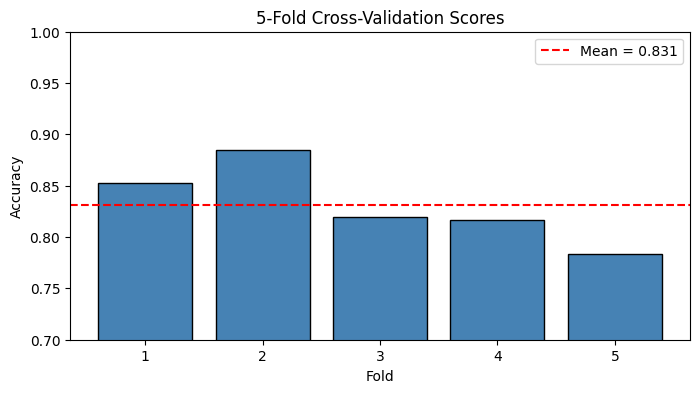

In [18]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# 5-Fold Cross Validation on best model
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

print(f"CV Scores:     {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

# Plot the CV scores
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.3f}')

plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Scores')
plt.ylim(0.7, 1.0)
plt.legend()

plt.show()

---
## ✍️ Section 9: Reflection Questions

Answer the following questions in the markdown cells below. Write 2–4 sentences for each.

**Q1: What is the key difference between a single Decision Tree and a Random Forest?  
Why does the Random Forest typically perform better?**

*Your Answer Here:*

**Q2: What does "feature importance" mean in the context of a Random Forest?  
Which feature was most important in your model, and does it make clinical sense?**

*Your Answer Here:*

**Q3: Your model may achieve very high training accuracy but slightly lower test accuracy.  
What is this phenomenon called, and how does Random Forest help mitigate it?**

*Your Answer Here:*

**Q4: In the medical context of heart disease prediction, which is more dangerous:  
a False Positive or a False Negative? How would you adjust your model to address this?**

*Your Answer Here:*

## ✍️ Section 9: Reflection (Very Short)

### **Q1: Decision Tree vs Random Forest**

A Decision Tree uses one model, while Random Forest uses many trees. Random Forest performs better because it reduces overfitting and gives more stable results.

---

### **Q2: Feature Importance**

Feature importance shows which features affect predictions most. In this model, **thalach, cp, and oldpeak** were most important, which makes sense medically.

---

### **Q3: Overfitting**

This is called overfitting, when training accuracy is higher than test accuracy. Random Forest reduces it by averaging many trees.

---

### **Q4: False Positive vs False Negative**

False Negative is more dangerous because a sick patient may be predicted as healthy. We can reduce it by improving recall or changing the threshold.



---
## 🌟 BONUS Section: Challenge Tasks

If you've finished everything above, try these extra challenges!

In [21]:
# 🌟 BONUS 1 — Feature Selection
# Use feature importances to keep only the top 7 features.
# Retrain the best Random Forest model on only those features.
# Does the model performance change?

# 💡 Hint: Use feat_df from Task 6.1 to get top 7 feature names.
#          Slice X with those column names: X_top = X[top_features]
#          Then redo the train-test split and re-evaluate.

# YOUR CODE HERE
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------
# Safety: ensure df exists
# -------------------------
if 'df' not in globals():
    import pandas as pd

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

    column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                    'restecg', 'thalach', 'exang', 'oldpeak',
                    'slope', 'ca', 'thal', 'target']

    df = pd.read_csv(url, na_values='?', names=column_names)

    df['ca'] = df['ca'].fillna(df['ca'].median())
    df['thal'] = df['thal'].fillna(df['thal'].median())
    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# -------------------------
# Features & Target
# -------------------------
X = df.drop('target', axis=1)
y = df['target']

# -------------------------
# Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# Train RF model
# -------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# -------------------------
# Feature importance (RECREATE feat_df)
# -------------------------
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# -------------------------
# TOP 7 FEATURES
# -------------------------
top_features = feat_df['Feature'].head(7).values

X_top = X[top_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# Retrain model
# -------------------------
model_top = RandomForestClassifier(n_estimators=100, random_state=42)
model_top.fit(X_train, y_train)

# -------------------------
# Evaluate
# -------------------------
y_pred = model_top.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Top 7 Features:", list(top_features))
print("Accuracy with Top Features:", acc)

Top 7 Features: ['thalach', 'thal', 'cp', 'ca', 'age', 'oldpeak', 'chol']
Accuracy with Top Features: 0.8524590163934426


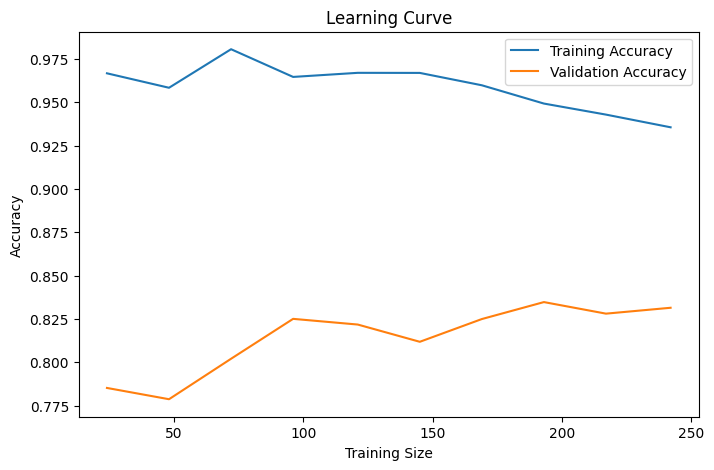

In [22]:
# 🌟 BONUS 2 — Learning Curve
# Plot a learning curve showing how training and validation accuracy
# change as the training set size increases.

# 💡 Hint: from sklearn.model_selection import learning_curve
#          train_sizes, train_scores, val_scores = learning_curve(
#              best_model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10))
#          Plot mean train and validation scores.

from sklearn.model_selection import learning_curve

# YOUR CODE HERE
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, val_mean, label='Validation Accuracy')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


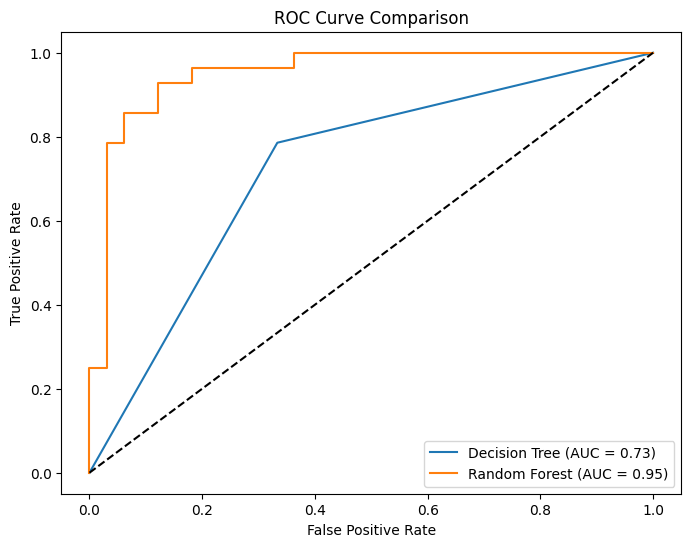

In [25]:
# 🌟 BONUS 3 — Compare with a Single Decision Tree
# Train a single DecisionTreeClassifier and compare its performance
# (accuracy, ROC-AUC) with your best Random Forest model.
# Plot both ROC curves on the same graph.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Re-create X_train, X_test, y_train, y_test with all features for best_model
# (X and y should still contain all original features after previous steps)
X_all_features = df.drop('target', axis=1)
y_all_features = df['target']
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_features, y_all_features,
    test_size=0.2,
    random_state=42,
    stratify=y_all_features
)

# -------------------------
# Decision Tree model
# (Train on the X_train with 7 features from Bonus 1, as intended for comparison)
# Note: If you want DT to also use all features, change X_train, y_train below
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train) # Using X_train from Bonus 1 (7 features)
dt_scores = dt.predict_proba(X_test)[:, 1] # Using X_test from Bonus 1 (7 features)

# -------------------------
# Random Forest model (best_model assumed)
# (best_model was trained on ALL features, so use X_test_all for prediction)
# -------------------------
rf_scores = best_model.predict_proba(X_test_all)[:, 1]

# -------------------------
# ROC curves
# -------------------------
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_scores) # Using y_test from Bonus 1
fpr_rf, tpr_rf, _ = roc_curve(y_test_all, rf_scores) # Using y_test_all for best_model

auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 6))

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

---
## 📋 Submission Checklist

Before submitting, make sure you have completed all of the following:

- [ ] Loaded and explored the dataset (Section 1 & 2)
- [ ] Handled missing values (Task 2.2)
- [ ] Created all 5 required visualizations (Section 3)
- [ ] Built and evaluated a baseline Random Forest model (Section 5)
- [ ] Plotted confusion matrix and ROC curve
- [ ] Analyzed feature importances (Section 6)
- [ ] Performed hyperparameter tuning with GridSearchCV (Section 7)
- [ ] Ran 5-fold cross-validation (Section 8)
- [ ] Answered all 4 reflection questions (Section 9)
- [ ] All plots have titles, axis labels, and legends
- [ ] Code is clean and well-commented

---
*Good luck! 🌲🌲🌲 Remember: A forest is always stronger than a single tree.*